# 02 - The small-world window ($L$ and $C$ vs $\beta$ and $k$)

In this notebook we make a quick analysis of the two structural metrics mentioned in the assignment:

* **$L$** — average path length (mean of the shortest-path distances between all pairs of nodes).
* **$C$** — clustering coefficient (fraction of length-2 paths that close into a triangle).

The goal is to observe the **small-world phenomenon**: starting from the regular ring lattice ($\beta=0$) and
rewiring edges with probability $\beta$, there is a window (≈ $\beta \in [10^{-2}, 10^{-1}]$)
where $L$ has already dropped to random-graph values but $C$ is still high as in the ring.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np

from src.smallworld.visualization import compute_metrics_data

## 1. Parameters and data

We define the parameters used for the experiment (exactly the same as those in the web documentation).

In [2]:
N        = 1000
K_VALUES = list(range(10, 101, 10))          # 10, 20, ..., 100
BETAS    = [0.0001, 0.001, 0.01, 0.1, 1.0]   # log scale
SEED     = 42
K_DEFAULT = 10                               # k the docs open by default

CACHE = ROOT / "data" / "metrics_analytics_data.json"
if CACHE.exists():
    with open(CACHE, encoding="utf-8") as fh:
        data = json.load(fh)
    print(f"Data loaded from the documentation cache: {CACHE.relative_to(ROOT)}")
else:
    print("Cache not found; recomputing with seed=42 (may take 1-3 min)...")
    data = compute_metrics_data(N=N, k_values=K_VALUES, betas=BETAS, seed=SEED)


def ws_metric(k, beta, metric):
    """L or C of WS(N, k, beta) as stored in the cache."""
    return data[str(k)]["ws"][f"{beta:g}"][metric]

Data loaded from the documentation cache: data\metrics_analytics_data.json


## 2. The small-world window for a fixed $k$

We take $k=10$ (the docs' default value). We compute $L(\beta)$ and $C(\beta)$ and
normalise them by the ring value ($\beta=0$), then plot them together on a log-$\beta$ scale.

In [3]:
k = K_DEFAULT

# Reference: regular ring (beta = 0)
L0 = data[str(k)]["ring"]["L"]
C0 = data[str(k)]["ring"]["C"]
print(f"Regular ring (beta=0):  L0 = {L0:.3f},  C0 = {C0:.3f}\n")

L_norm, C_norm = [], []
for beta in BETAS:
    L = ws_metric(k, beta, "L")
    C = ws_metric(k, beta, "C")
    L_norm.append(L / L0)
    C_norm.append(C / C0)
    print(f"beta={beta:<7} L={L:7.3f} (L/L0={L/L0:.3f})   C={C:.3f} (C/C0={C/C0:.3f})")

Regular ring (beta=0):  L0 = 50.450,  C0 = 0.667

beta=0.0001  L= 38.499 (L/L0=0.763)   C=0.666 (C/C0=1.000)
beta=0.001   L= 33.854 (L/L0=0.671)   C=0.666 (C/C0=0.999)
beta=0.01    L=  9.387 (L/L0=0.186)   C=0.647 (C/C0=0.971)
beta=0.1     L=  4.472 (L/L0=0.089)   C=0.488 (C/C0=0.732)
beta=1.0     L=  3.271 (L/L0=0.065)   C=0.009 (C/C0=0.013)


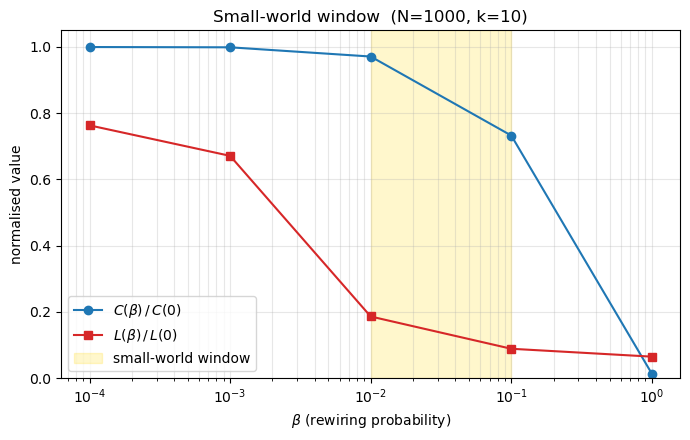

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(BETAS, C_norm, "o-", color="#1f77b4", label=r"$C(\beta)\,/\,C(0)$")
ax.plot(BETAS, L_norm, "s-", color="#d62728", label=r"$L(\beta)\,/\,L(0)$")

# Band highlighting the small-world window
ax.axvspan(0.01, 0.1, color="gold", alpha=0.2, label="small-world window")

ax.set_xscale("log")
ax.set_xlabel(r"$\beta$ (rewiring probability)")
ax.set_ylabel("normalised value")
ax.set_title(f"Small-world window  (N={N}, k={k})")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, which="both", alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES / "02_small_world_window.png", dpi=150)
plt.show()

**Reading the plot.** $L(\beta)/L(0)$ (red) drops almost vertically around $\beta \approx 10^{-2}$:
just a few random rewirings are enough to drastically shorten distances.
In contrast $C(\beta)/C(0)$ (blue) stays high until $\beta \approx 10^{-1}$, because rewiring
a single edge only breaks a few local triangles. The gap between the two curves
(golden area) is exactly the **small-world regime**: short distances + high clustering.

## 3. Effect of different $k$

We repeat the process for $k \in \{10, 20, \dots, 100\}$.
This checks whether the window is robust or depends on the number of neighbours.

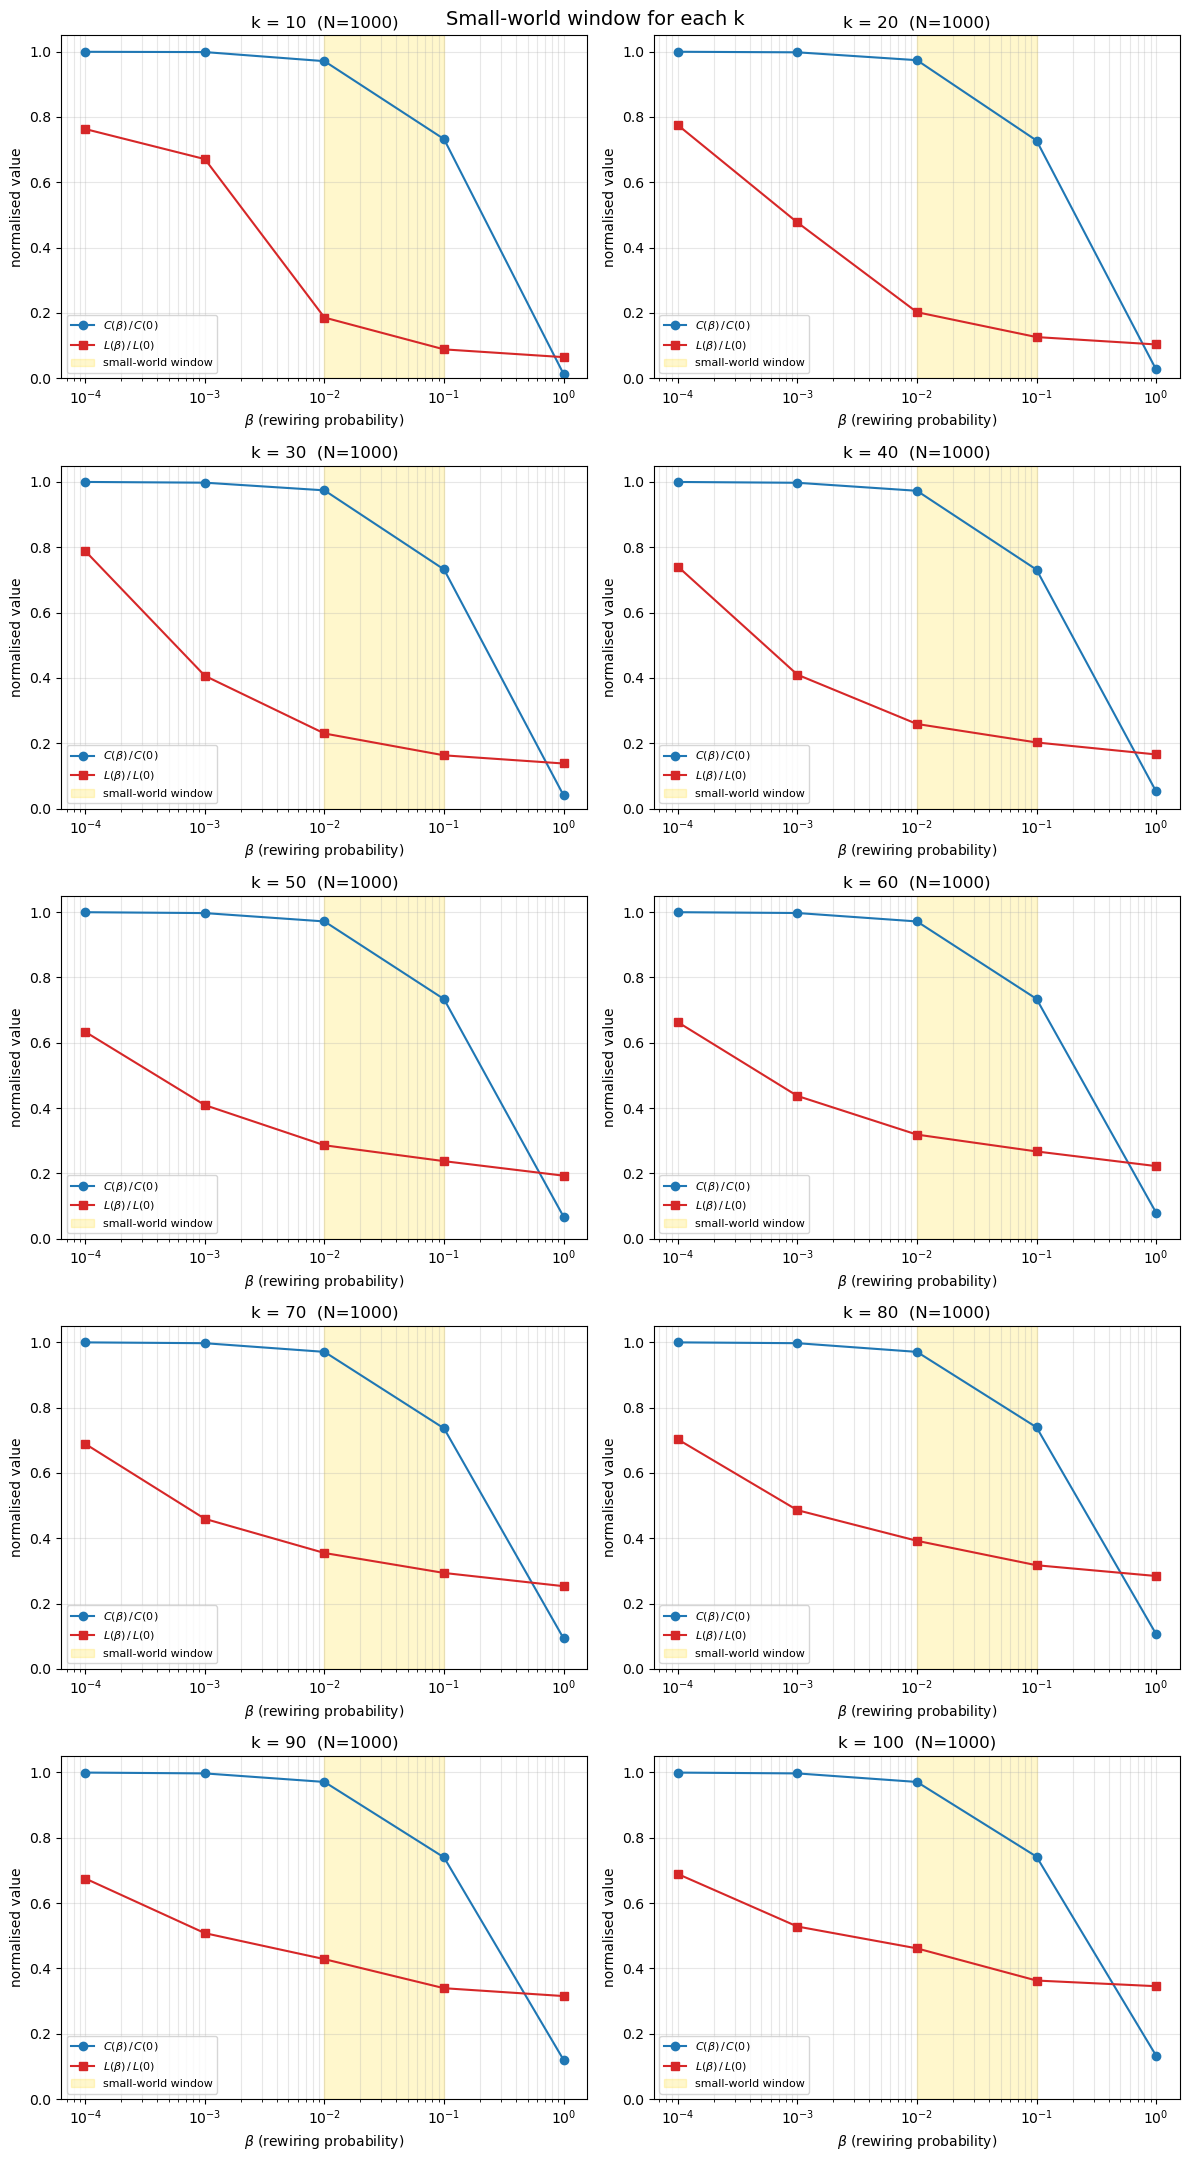

In [5]:
fig, axes = plt.subplots(5, 2, figsize=(12, 22))

for ax, kk in zip(axes.flat, K_VALUES):
    L0k = data[str(kk)]["ring"]["L"]
    C0k = data[str(kk)]["ring"]["C"]
    L_norm_k = [ws_metric(kk, b, "L") / L0k for b in BETAS]
    C_norm_k = [ws_metric(kk, b, "C") / C0k for b in BETAS]

    ax.plot(BETAS, C_norm_k, "o-", color="#1f77b4", label=r"$C(\beta)\,/\,C(0)$")
    ax.plot(BETAS, L_norm_k, "s-", color="#d62728", label=r"$L(\beta)\,/\,L(0)$")

    # Band highlighting the small-world window
    ax.axvspan(0.01, 0.1, color="gold", alpha=0.2, label="small-world window")

    ax.set_xscale("log")
    ax.set_xlabel(r"$\beta$ (rewiring probability)")
    ax.set_ylabel("normalised value")
    ax.set_title(f"k = {kk}  (N={N})")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Small-world window for each k", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES / "02_window_per_k.png", dpi=150)
plt.show()

**Reading.** Even though $C(\beta)/C(0)$ barely changes with $k$, and $L(\beta)/L(0)$ does change its behaviour a little —it is reasonable to expect the average distance between pairs of nodes to drop as each node has more neighbours—, the **small-world phenomenon holds independently of $k$**: in every subplot $C$ stays close to 1 while $L$ has already started to fall, so the relative gap between the two metrics (the golden window) always appears.

## 4. Comparison of the three networks

Finally, we place side by side the regular ring lattice, the Watts–Strogatz with $\beta=0.1$ (small-world phenomenon) and the Erdős–Rényi, all with $N=1000$ and $k=10$.

In [6]:
k = K_DEFAULT
rows = {
    "Regular ring (beta=0)":      (data[str(k)]["ring"]["L"], data[str(k)]["ring"]["C"]),
    "Watts-Strogatz (beta=0.1)":  (ws_metric(k, 0.1, "L"),    ws_metric(k, 0.1, "C")),
    "Erdos-Renyi":                (data[str(k)]["er"]["L"],   data[str(k)]["er"]["C"]),
}

print(f"{'Network':<28}{'L':>8}{'C':>8}")
print("-" * 44)
for name, (L, C) in rows.items():
    print(f"{name:<28}{L:>8.3f}{C:>8.3f}")

Network                            L       C
--------------------------------------------
Regular ring (beta=0)         50.450   0.667
Watts-Strogatz (beta=0.1)      4.472   0.488
Erdos-Renyi                    3.259   0.011


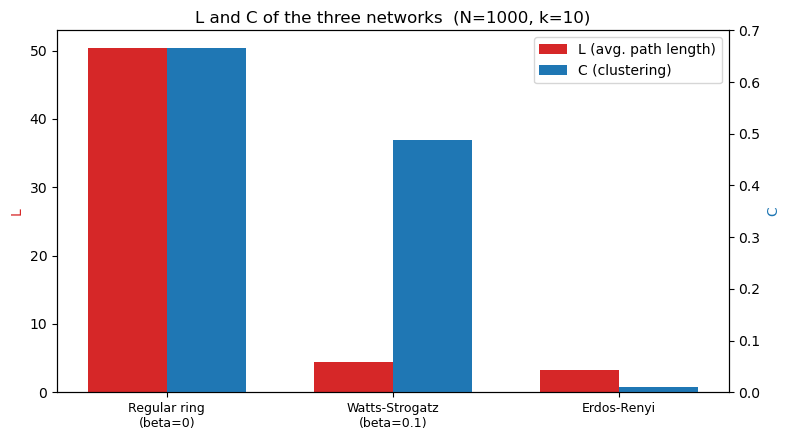

In [7]:
names = list(rows.keys())
Ls = [rows[n][0] for n in names]
Cs = [rows[n][1] for n in names]
x = np.arange(len(names))
w = 0.35

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax2 = ax1.twinx()
ax1.bar(x - w / 2, Ls, w, color="#d62728", label="L (avg. path length)")
ax2.bar(x + w / 2, Cs, w, color="#1f77b4", label="C (clustering)")

ax1.set_ylabel("L", color="#d62728")
ax2.set_ylabel("C", color="#1f77b4")
ax1.set_xticks(x)
ax1.set_xticklabels([n.replace(" (", "\n(") for n in names], fontsize=9)
ax1.set_title(f"L and C of the three networks  (N={N}, k={k})")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

fig.tight_layout()
fig.savefig(FIGURES / "02_three_networks_LC.png", dpi=150)
plt.show()

## 5. Conclusions

- **L falls much earlier than C.** A value of $\beta \approx 10^{-2}$ (a few random
  rewirings) is enough to reduce the average path length almost to that of a random graph, while
  clustering does not really start to drop until $\beta \approx 10^{-1}$.
- **The small-world window** ($\beta \in [10^{-2}, 10^{-1}]$) is the region where small
  $L$ (like Erdős–Rényi) and high $C$ (like the ring) coexist.
- **It is robust in $k$.** The behaviour repeats for every $k \in \{10,\dots,100\}$;
  increasing $k$ only makes the window slightly wider, without changing its nature.
- **The three networks** confirm the theoretical values: the ring has large $L$ and large $C$,
  the Erdős–Rényi has small $L$ and almost zero $C$, and the Watts–Strogatz inside the window
  combines the best of both worlds.